In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("/content/Sample - Superstore.csv",encoding="latin-1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.shape

(9994, 21)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df['Order Date']=pd.to_datetime(df['Order Date'])

df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
#How many days it took to deliver each order
'''🏪 In business terms

For a retail company:

Faster delivery = happier customers

Slower delivery = complaints, returns, bad reviews'''


df['Delivery Days']=(df['Ship Date'] - df['Order Date']).dt.days   # this means, it give only the days difference not the time

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Delivery Days'],
      dtype='object')

In [ ]:
df[['Order Date','Ship Date', 'Delivery Days']].head()

,Order Date,Ship Date,Delivery Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [ ]:
# Ship Mode business insight
# Average Delivery Days for each Ship Mode

avg_delivery = df.groupby('Ship Mode')['Delivery Days'].mean()
avg_delivery


,Delivery Days
Ship Mode,
First Class,2.182705
Same Day,0.044199
Second Class,3.238046
Standard Class,5.006535


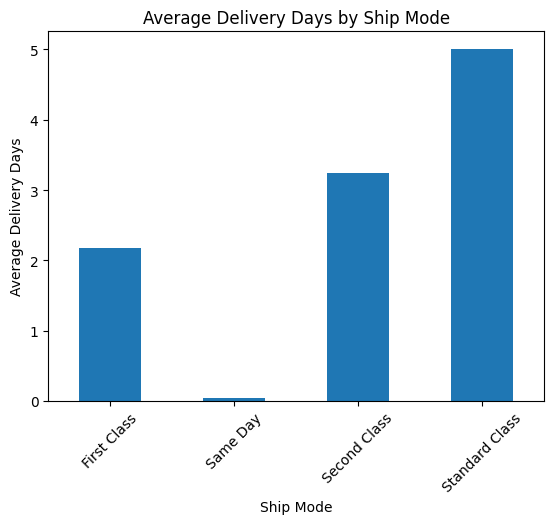

In [ ]:
#Visualization of delivery days

# Key Point : Group → calculate → visualize

import matplotlib.pyplot as plt

plt.figure()
avg_delivery.plot(kind='bar')
plt.title("Average Delivery Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Sales & profit overview

total_sales = ( df['Sales'].sum() ) / 1000000  # just to read in dollars
total_profit = (df['Profit'].sum() ) / 1000000

round(total_sales,2) , round(total_profit,2)

(np.float64(2.3), np.float64(0.29))

In [ ]:
# Profit by Category

category_profit = df.groupby('Category')['Profit'].sum()
category_profit


,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


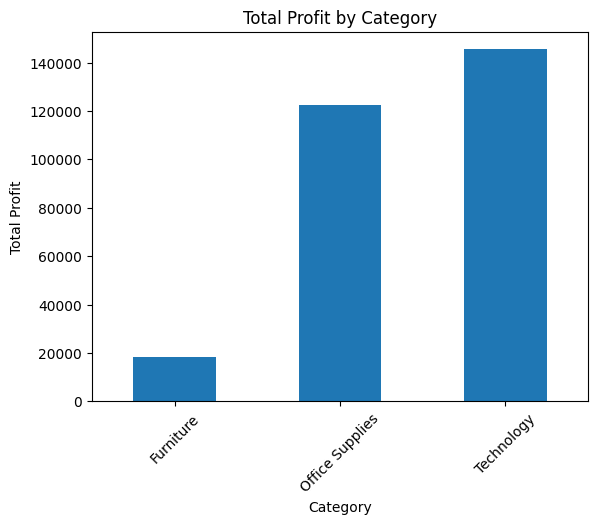

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
category_profit.plot(kind='bar')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#To know about the each category products revenue, we move to Sub-Category

sub_category_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
sub_category_profit



,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


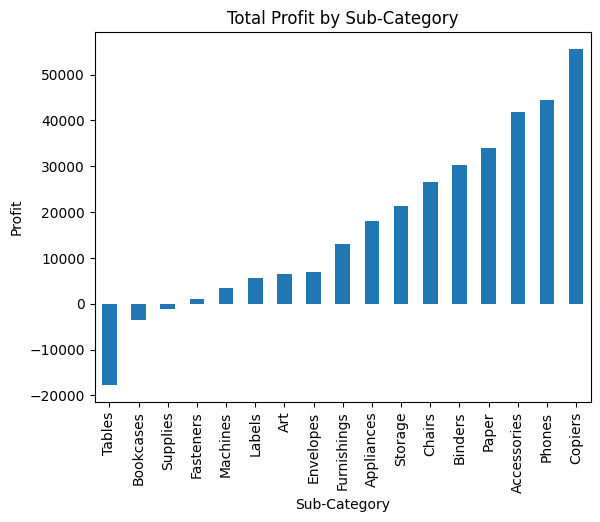

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
sub_category_profit.plot(kind='bar')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.show()

In [ ]:
tables = df[df['Sub-Category'] == 'Tables']
tables.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Days
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
10,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,5
24,25,CA-2015-106320,2015-09-25,2015-09-30,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649,5
117,118,CA-2015-110457,2015-03-02,2015-03-06,Standard Class,DK-13090,Dave Kipp,Consumer,United States,Seattle,...,West,FUR-TA-10001768,Furniture,Tables,Hon Racetrack Conference Tables,787.5300,3,0.00,165.3813,4
125,126,US-2014-134614,2014-09-20,2014-09-25,Standard Class,PF-19165,Philip Fox,Consumer,United States,Bloomington,...,Central,FUR-TA-10004534,Furniture,Tables,Bevis 44 x 96 Conference Tables,617.7000,6,0.50,-407.6820,5


In [ ]:
#finding average of discount and profit of TABLES

tables['Discount'].mean(), tables['Profit'].mean()




(np.float64(0.26128526645768024), np.float64(-55.56577147335423))

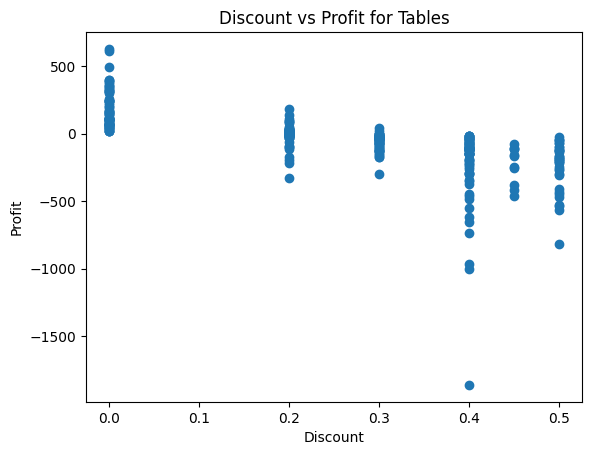

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(tables['Discount'],tables['Profit'])
plt.title("Discount vs Profit for Tables")
plt.xlabel("Discount")
plt.ylabel('Profit')
plt.show()

In [ ]:
tables['Discount_Rounded'] = tables['Discount'].round(1)

tables.groupby('Discount_Rounded')['Profit'].mean().sort_index()

/tmp/ipython-input-443/4188372242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tables['Discount_Rounded'] = tables['Discount'].round(1)


,Profit
Discount_Rounded,
0.0,184.393051
0.2,-4.275465
0.3,-63.006067
0.4,-217.215208
0.5,-239.316314


In [ ]:
# This is about Machines

Machines = df[df['Sub-Category'] == 'Machines']
Machines.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Days
165,166,CA-2014-139892,2014-09-08,2014-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,Central,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,8159.952,8,0.4,-1359.9920,4
215,216,CA-2015-146262,2015-01-02,2015-01-09,Standard Class,VW-21775,Victoria Wilson,Corporate,United States,Medina,...,East,TEC-MA-10000864,Technology,Machines,Cisco 9971 IP Video Phone Charcoal,1188.000,9,0.7,-950.4000,7
223,224,CA-2015-169397,2015-12-24,2015-12-27,First Class,JB-15925,Joni Blumstein,Consumer,United States,Dublin,...,East,TEC-MA-10001148,Technology,Machines,Swingline SM12-08 MicroCut Jam Free Shredder,479.988,4,0.7,-383.9904,3
262,263,US-2014-106992,2014-09-19,2014-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,Central,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,3059.982,3,0.4,-509.9970,2
263,264,US-2014-106992,2014-09-19,2014-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,Central,TEC-MA-10003353,Technology,Machines,Xerox WorkCentre 6505DN Laser Multifunction Pr...,2519.958,7,0.4,-251.9958,2


In [ ]:
Machines['Discount'].mean() , Machines['Profit'].mean()

(np.float64(0.3060869565217392), np.float64(29.432668695652172))

In [ ]:
Machines['Discount_Rounded'] = Machines['Discount'].round(1)

Machines.groupby('Discount_Rounded')['Profit'].mean().sort_index()

/tmp/ipython-input-443/28181149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Machines['Discount_Rounded'] = Machines['Discount'].round(1)


,Profit
Discount_Rounded,
0.0,935.786976
0.1,416.042150
0.2,160.329110
0.3,65.207900
0.4,-205.141800
0.5,-636.269092
0.7,-851.274743


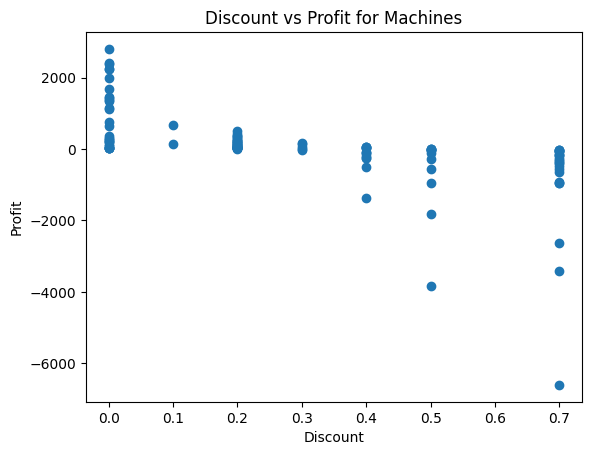

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(Machines['Discount'],Machines['Profit'])
plt.title("Discount vs Profit for Machines")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [ ]:
#Advanced level

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M")

monthly_trend = df.groupby("YearMonth")[["Sales","Profit"]].sum()

monthly_trend.index = monthly_trend.index.to_timestamp()

monthly_trend.head()

,Sales,Profit
YearMonth,,
2014-01-01,14236.895,2450.1907
2014-02-01,4519.892,862.3084
2014-03-01,55691.009,498.7299
2014-04-01,28295.345,3488.8352
2014-05-01,23648.287,2738.7096


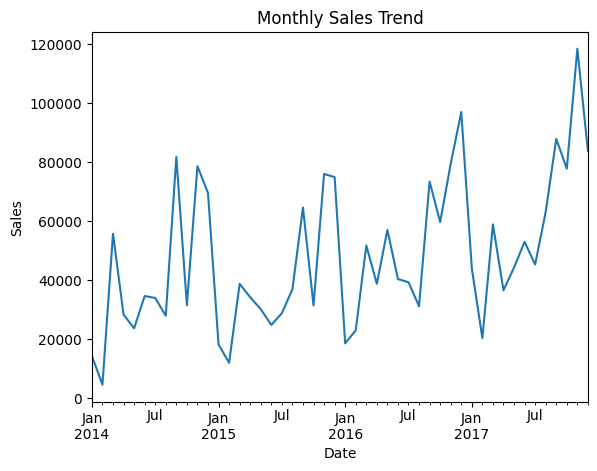

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
monthly_trend["Sales"].plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

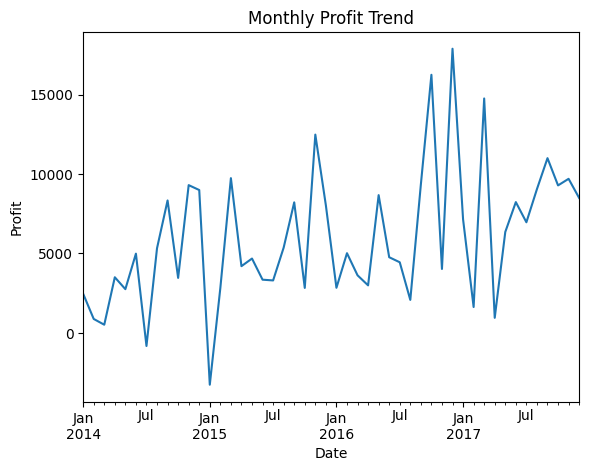

In [ ]:
# PROFIT TREND

plt.figure()
monthly_trend["Profit"].plot()
plt.title("Monthly Profit Trend")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.show()

In [ ]:
monthly_trend[monthly_trend["Profit"]<0]

,Sales,Profit
YearMonth,,
2014-07-01,33946.3930,-841.4826
2015-01-01,18174.0756,-3281.0070


<Axes: xlabel='YearMonth'>

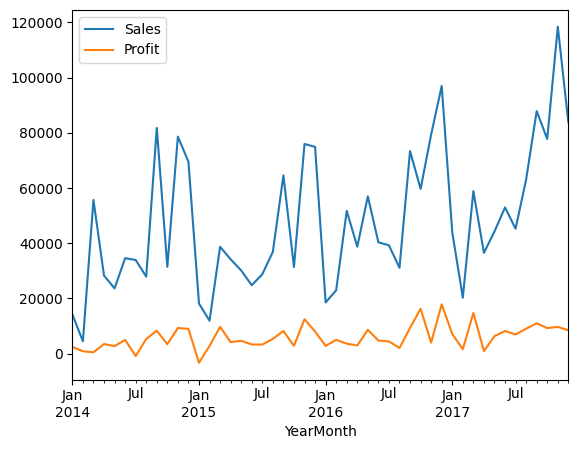

In [ ]:

monthly_trend.plot()

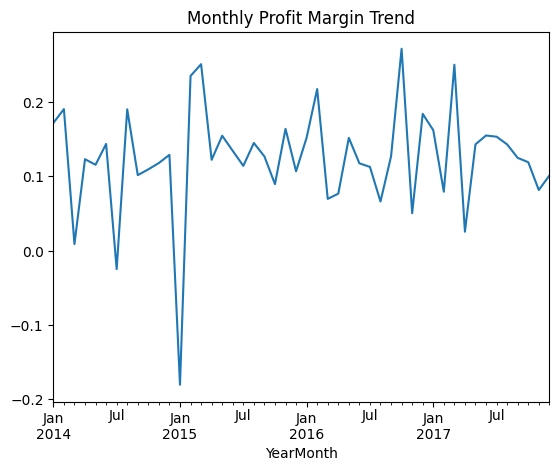

In [ ]:
monthly_trend["Profit_Margin"] = monthly_trend["Profit"] / monthly_trend["Sales"]

monthly_trend["Profit_Margin"].plot()
plt.title("Monthly Profit Margin Trend")
plt.show()


In [ ]:
'''Although revenue shows consistent upward growth,
profit margins exhibit high volatility with occasional negative dips,
indicating unstable cost structures and discount-driven sales strategies.'''

'Although revenue shows consistent upward growth,\nprofit margins exhibit high volatility with occasional negative dips,\nindicating unstable cost structures and discount-driven sales strategies.'

In [ ]:
"Correlation between discount and profit"

df[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [ ]:
#Interpretation:

#Higher discounts are associated with lower profits, but discounting alone does not fully explain profit volatility.

In [ ]:
# Profit by Category

category_margin = df.groupby("Category").agg({
    "Sales":"sum",
    "Profit":"sum"
})

category_margin["Margin"] = category_margin["Profit"] / category_margin["Sales"]

category_margin.sort_values("Margin")

,Sales,Profit,Margin
Category,,,
Furniture,741999.7953,18451.2728,0.024867
Office Supplies,719047.0320,122490.8008,0.170352
Technology,836154.0330,145454.9481,0.173957


In [ ]:
# Create YearMonth column if not already created
df["YearMonth"] = df["Order Date"].dt.to_period("M")

# Monthly total sales
monthly_total = df.groupby("YearMonth")["Sales"].sum().reset_index()

# Monthly furniture sales
monthly_furniture = df[df["Category"]=="Furniture"] \
                        .groupby("YearMonth")["Sales"].sum().reset_index()

# Merge both
monthly_compare = monthly_total.merge(monthly_furniture,
                                      on="YearMonth",
                                      suffixes=("_Total","_Furniture"))

# Calculate furniture contribution %
monthly_compare["Furniture_Share"] = (
    monthly_compare["Sales_Furniture"] /
    monthly_compare["Sales_Total"]
)

monthly_compare.head()

,YearMonth,Sales_Total,Sales_Furniture,Furniture_Share
0,2014-01,14236.895,6242.525,0.438475
1,2014-02,4519.892,1839.658,0.407014
2,2014-03,55691.009,14573.956,0.261693
3,2014-04,28295.345,7944.837,0.280782
4,2014-05,23648.287,6912.787,0.292317


In [ ]:
monthly_profit = df.groupby("YearMonth")["Profit"].sum().reset_index()

monthly_compare = monthly_compare.merge(monthly_profit,
                                        on="YearMonth")

monthly_compare.head()

,YearMonth,Sales_Total,Sales_Furniture,Furniture_Share,Profit
0,2014-01,14236.895,6242.525,0.438475,2450.1907
1,2014-02,4519.892,1839.658,0.407014,862.3084
2,2014-03,55691.009,14573.956,0.261693,498.7299
3,2014-04,28295.345,7944.837,0.280782,3488.8352
4,2014-05,23648.287,6912.787,0.292317,2738.7096


In [ ]:
monthly_compare[["Furniture_Share","Profit"]].corr()

,Furniture_Share,Profit
Furniture_Share,1.000000,-0.302212
Profit,-0.302212,1.000000


In [ ]:
#Region margin

region_margin = df.groupby("Region").agg({
    "Sales":"sum",
    "Profit":"sum"
})

region_margin["Margin"] = region_margin["Profit"] / region_margin["Sales"]

region_margin.sort_values("Margin")

,Sales,Profit,Margin
Region,,,
Central,501239.8908,39706.3625,0.079216
South,391721.9050,46749.4303,0.119343
East,678781.2400,91522.7800,0.134834
West,725457.8245,108418.4489,0.149448


In [ ]:
#Furniture Region

furniture_region = df[df["Category"]=="Furniture"] \
                    .groupby("Region") \
                    .agg({"Sales":"sum","Profit":"sum"})

furniture_region["Margin"] = furniture_region["Profit"] / furniture_region["Sales"]

furniture_region.sort_values("Margin")

,Sales,Profit,Margin
Region,,,
Central,163797.1638,-2871.0494,-0.017528
East,208291.2040,3046.1658,0.014625
West,252612.7435,11504.9503,0.045544
South,117298.6840,6771.2061,0.057726


In [ ]:
'''
Profit instability happens because:

Furniture has structurally weak margins

In Central region, Furniture is loss-making

When Central sells more Furniture,
→ overall monthly profit drops
→ causing volatility and negative months

This is no longer assumption.'''

'\nProfit instability happens because:\n\nFurniture has structurally weak margins\n\nIn Central region, Furniture is loss-making\n\nWhen Central sells more Furniture,\n→ overall monthly profit drops\n→ causing volatility and negative months\n\nThis is no longer assumption.'

In [ ]:
#Now to identify which category in furniture making significagnt losses

furniture = df[df["Category"]=="Furniture"]

sub_margin = furniture.groupby("Sub-Category").agg({
    "Sales":"sum",
    "Profit":"sum"
})

sub_margin["Margin"] = sub_margin["Profit"] / sub_margin["Sales"]

sub_margin.sort_values("Margin")

,Sales,Profit,Margin
Sub-Category,,,
Tables,206965.5320,-17725.4811,-0.085645
Bookcases,114879.9963,-3472.5560,-0.030228
Chairs,328449.1030,26590.1663,0.080957
Furnishings,91705.1640,13059.1436,0.142404


In [ ]:
'''

 Full Root Cause Chain (Crystal Clear)
1️->  Tables are heavily loss-making (-8.5%)
2️->  Bookcases also weak (-3%)
3️->  Furniture overall margin only 2.4%
4️->  In Central region → Furniture is negative (-1.75%)
5️->  When Furniture share increases → Profit decreases (Correlation -0.32) '''

'\n\n Full Root Cause Chain (Crystal Clear)\n1️->  Tables are heavily loss-making (-8.5%)\n2️->  Bookcases also weak (-3%)\n3️->  Furniture overall margin only 2.4%\n4️->  In Central region → Furniture is negative (-1.75%)\n5️->  When Furniture share increases → Profit decreases (Correlation -0.32) '

In [ ]:
df['Profit'].describe()


,Profit
count,9994.000000
mean,28.656896
std,234.260108
min,-6599.978000
25%,1.728750
50%,8.666500
75%,29.364000
max,8399.976000


In [ ]:
df['Profit'].min(), df['Profit'].max()

(-6599.978, 8399.976)

In [ ]:
#Define Target variable
y=df['Profit']

#Define Features

X=df[['Sales','Quantity','Discount','Delivery Days','Category','Sub-Category','Region','Ship Mode']]

In [ ]:
#since linear regression cannot handle text
#conver categories into dummy variable

X=pd.get_dummies(X,drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
#now evaluating the model
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
mae=mean_absolute_error(y_test,y_pred)

print("R2 score:",r2)
print("RMSE:",rmse)
print("MAE:",mae)

R2 score: -0.6450130108852457
RMSE: 282.41576215789433
MAE: 67.77827672711253


In [ ]:
# Now that we have got R2 score a neagative value, we need to fix it.
# we begin by checking profit distribution.

In [ ]:
df['Profit'].describe()

,Profit
count,9994.000000
mean,28.656896
std,234.260108
min,-6599.978000
25%,1.728750
50%,8.666500
75%,29.364000
max,8399.976000


In [ ]:
df['Profit'].max() , df['Profit'].min()

(8399.976, -6599.978)

In [ ]:
#the dataset contains, extreme endpoints from negative to positive, these are called outliers.
#This means profit distribution is unstable.

#Now i move into IQR modeling. that is to rebuild the model, by removing extreme endpoints

In [ ]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['Profit'] >= lower_bound) & (df['Profit'] <= upper_bound)]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (9994, 24)
Cleaned shape: (8113, 24)


In [ ]:
df_clean['Profit'].describe()

,Profit
count,8113.000000
mean,11.604086
std,18.641425
min,-39.637000
25%,2.049200
50%,7.257600
75%,19.034400
max,70.722000


In [ ]:
y = df_clean['Profit']

X= df_clean[['Sales','Discount','Delivery Days','Sub-Category','Region','Segment','Ship Mode']]

In [ ]:
#This is for encode categorical values, i.e., to convert non-numerical values into numerical data

'''
The error you're seeing indicates that the VIF calculation is trying to perform numerical operations on boolean values (True/False)
which it doesn't support directly.
This typically happens when dummy variables created by pd.get_dummies are still in boolean format.
 To fix this, I'll modify the cell where pd.get_dummies is applied to explicitly convert these boolean columns to integers.
'''


X = pd.get_dummies(X, drop_first=True).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2 Score: 0.21030027425633824
RMSE: 17.034776532666434
MAE: 11.638559141835705


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
8,Sub-Category_Copiers,20.379588
21,Region_West,5.595327
20,Region_South,3.556189
19,Region_East,3.130674
24,Ship Mode_Same Day,1.365378
25,Ship Mode_Second Class,1.041594
9,Sub-Category_Envelopes,0.886837
23,Segment_Home Office,0.779679
26,Ship Mode_Standard Class,0.251469
14,Sub-Category_Paper,0.233368


In [ ]:
coefficients.sort_values(by='Coefficient').head(10)

,Feature,Coefficient
18,Sub-Category_Tables,-25.453258
6,Sub-Category_Bookcases,-22.943735
7,Sub-Category_Chairs,-22.029260
16,Sub-Category_Storage,-11.980319
17,Sub-Category_Supplies,-11.610807
13,Sub-Category_Machines,-10.523641
10,Sub-Category_Fasteners,-9.883144
5,Sub-Category_Binders,-9.308229
4,Sub-Category_Art,-7.814869
11,Sub-Category_Furnishings,-5.196659


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Add constant for VIF calculation
import statsmodels.api as sm
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data.sort_values(by="VIF", ascending=False).head(10)


#The reason i got VIF infinite is due to category and subcategory belongs to same .
#That creates perfect linear dependency. and perfect multicolinearity. so i remove this category in features.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Feature,VIF
0,const,28.388570
27,Ship Mode_Standard Class,3.911726
3,Delivery Days,3.110339
6,Sub-Category_Binders,2.681311
15,Sub-Category_Paper,2.601505
12,Sub-Category_Furnishings,2.153300
5,Sub-Category_Art,2.091451
26,Ship Mode_Second Class,1.995180
17,Sub-Category_Storage,1.957423
16,Sub-Category_Phones,1.887702
